In [ ]:
from transformers import AutoConfig
config = AutoConfig.from_pretrained("HuggingFaceTB/SmolLM-135M")
print(config)

In [2]:
import sys
sys.path.append('..')

import importlib
import model
import config

importlib.reload(model)
importlib.reload(config)

from model import Attention , MLP , RMSNorm , Block , MalyLLM
from config import SmallTransformerConfig
import torch

In [3]:
x = torch.rand(32,128,576)
att = Attention(SmallTransformerConfig())
mlp = MLP(SmallTransformerConfig())
hidden_dim= SmallTransformerConfig().hidden_dim

norm = RMSNorm(hidden_dim)

y = att(x)
y = mlp(x)
y = norm(x)

y.shape

torch.Size([32, 128, 576])

In [4]:
y[:, :, -1].shape

torch.Size([32, 128])

In [25]:
blok =  Block(SmallTransformerConfig())
y = blok(x)

y.shape

torch.Size([32, 128, 576])

In [4]:
m = MalyLLM(SmallTransformerConfig())

sum(p.numel() for p in m.parameters())


134515008

In [ ]:
x , y = torch.load("../Data/Debug_batch.pt")



logits , loss =m(x,y)

loss

In [28]:
import math


math.log(SmallTransformerConfig().vocab_size)

10.802672816507345

In [40]:
optimizer = torch.optim.AdamW(m.parameters() , lr =1e-3)
device = "cuda"

m.to(device)
x , y = x.to(device) , y.to(device)

for i in range(100):
    logits , loss = m(x,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"step{i} , loss:{loss}")



step0 , loss:3.6646885871887207
step1 , loss:3.8130712509155273
step2 , loss:3.953810453414917
step3 , loss:3.6979079246520996
step4 , loss:3.761026620864868
step5 , loss:3.5903480052948
step6 , loss:3.5105464458465576
step7 , loss:3.4482572078704834
step8 , loss:3.4162533283233643
step9 , loss:3.3969504833221436
step10 , loss:3.3934271335601807
step11 , loss:3.3230676651000977
step12 , loss:3.309520959854126
step13 , loss:3.3007307052612305
step14 , loss:3.2581706047058105
step15 , loss:3.2188878059387207
step16 , loss:3.162896156311035
step17 , loss:3.146278142929077
step18 , loss:3.1817848682403564
step19 , loss:3.1498055458068848
step20 , loss:3.0722153186798096
step21 , loss:3.0104615688323975
step22 , loss:3.0201256275177
step23 , loss:2.954090118408203
step24 , loss:2.8610610961914062
step25 , loss:2.7708895206451416
step26 , loss:2.707059383392334
step27 , loss:2.6961781978607178
step28 , loss:2.704271078109741
step29 , loss:2.5854592323303223
step30 , loss:2.450730085372925
st

In [39]:
x.shape

torch.Size([1, 99])

In [ ]:
model = MalyLLM(SmallTransformerConfig())
model = model.cuda()


import torch
print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

In [ ]:
import gc
del model, x, logits, loss , m
gc.collect()

torch.cuda.empty_cache()
print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

In [ ]:
import sys
sys.path.append('..')

import importlib
import model
import config

importlib.reload(model)
importlib.reload(config)

from model import  MalyLLM
from config import SmallTransformerConfig
import torch

m = MalyLLM(SmallTransformerConfig())
m.cuda()
m = torch.compile(m)
torch.set_float32_matmul_precision('high')

x = torch.randint(0, 49152, (16, 2048)).cuda() 

optim = torch.optim.AdamW(m.parameters() , fused= True) 

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    logits, loss = m(x , target = x)

loss.backward()
optim.step()

total_vram = torch.cuda.max_memory_allocated()/1e9

print(f"VRAM z batch: {total_vram:.2f} GB")


In [ ]:
import os
nproces = max(1,os.cpu_count()//2)
nproces

3.0

In [1]:
import torch

torch.version.cuda

'12.6'

In [1]:
import huggingface_hub
import shutil

path = huggingface_hub.hf_hub_download(
    repo_id="ArekStaron/MalyLLM",
    filename="log.txt"
)

shutil.copy(path,"log.txt")


log.txt: 0.00B [00:00, ?B/s]

'log.txt'

In [4]:
with open("log.txt" , "r") as f:
    lines = f.readlines()

steps = []
val_losses = []

for line in lines:
    line = line.split()
    step = line[0]
    val_loss = line[2]
    steps.append(int(step))
    val_losses.append(float(val_loss))





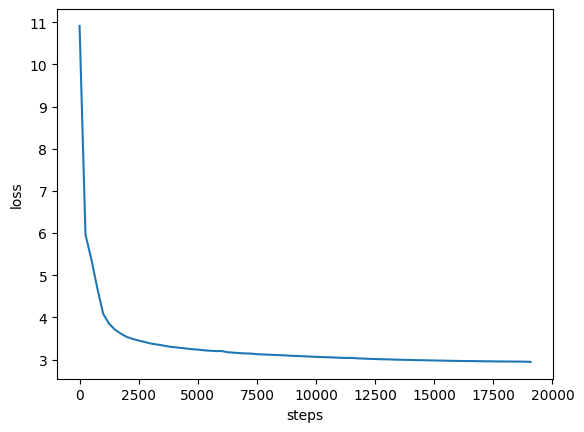

In [7]:
import matplotlib.pyplot as plt

plt.ylabel("loss")
plt.xlabel("steps")
plt.plot(steps , val_losses)
